# 🔬 Breast Cancer Segmentation — U-Net Pipeline
**Dataset:** BUSI (Breast Ultrasound Images)  
**Task:** Binary segmentation of tumor regions  
**Model:** U-Net with pretrained ResNet34 encoder (via `segmentation_models_pytorch`)

## 0. Install Dependencies

In [ ]:
# Run once to install required packages
# !pip install segmentation-models-pytorch albumentations opencv-python-headless

In [1]:
%pip install segmentation-models-pytorch albumentations opencv-python-headless


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.6 MB 1.4 MB/s eta 0:00:02
   -------- ------------------------------- 0.5/2.6 MB 1.4 MB/s eta 0:00:02
   ------------ --------------------------- 0.8/2.6 MB 1.2 MB/s eta 0:00:02
   ------------ --------------------------- 0.8/2.6 MB 1.2 MB/s eta 0:00:02
   ---------------- ----------------------- 1.0/2.6 MB 898.8 kB/s eta 0:00:02
   -------------------- ------------------- 1.3/2.6 MB 944.7 kB/s eta 0:00:02
   ------------------------ --------------- 1.6/2.6 MB 963.8 kB/s eta 0:00:02
   ---------------------------- ----------- 1.8/2.6 MB 1.0 MB/s eta 0:00:01
   ------------------------------------ --- 2.4/2.6 MB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 1.1 MB/s eta 0:00:00


## 1. Imports & Configuration

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# ─── Config ──────────────────────────────────────────────────────────────────
class CFG:
    # Paths
    IMG_DIR      = r"C:\ornekler\jupyter\deep_learning\breast-cancer\processed\segmentation\images"
    MASK_DIR     = r"C:\ornekler\jupyter\deep_learning\breast-cancer\processed\segmentation\masks"
    SAVE_DIR     = r"C:\ornekler\jupyter\deep_learning\breast-cancer\outputs"
    PRED_DIR     = r"C:\ornekler\jupyter\deep_learning\breast-cancer\predicted_masks"

    # Model
    ENCODER      = "resnet34"       # Pretrained encoder backbone
    ENCODER_WEIGHTS = "imagenet"
    IN_CHANNELS  = 3               # U-Net input channels (convert gray → 3ch)
    NUM_CLASSES  = 1               # Binary segmentation

    # Training
    IMAGE_SIZE   = 256
    BATCH_SIZE   = 8
    NUM_EPOCHS   = 50
    LR           = 1e-4
    VAL_SPLIT    = 0.2
    SEED         = 42
    DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

    # Loss weights
    BCE_WEIGHT   = 0.5
    DICE_WEIGHT  = 0.5

os.makedirs(CFG.SAVE_DIR, exist_ok=True)
os.makedirs(CFG.PRED_DIR, exist_ok=True)

print(f"Device : {CFG.DEVICE}")
print(f"Image size: {CFG.IMAGE_SIZE}x{CFG.IMAGE_SIZE}")

c:\Users\dellg\AppData\Local\Programs\Python\Python311\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.22). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Device : cuda
Image size: 256x256


## 2. Dataset Class

In [2]:
class BUSIDataset(Dataset):
    """
    Custom Dataset for BUSI segmentation.
    Expects:
      images/ → *.png  (grayscale or RGB ultrasound images)
      masks/  → *_mask.png  (binary masks, same base name)
    """

    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # ── Load image ──────────────────────────────────────────────────────
        image = cv2.imread(self.image_paths[idx])          # BGR, uint8
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)     # → RGB

        # ── Load mask ───────────────────────────────────────────────────────
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)  # uint8

        # Ensure mask is strictly binary {0, 1}
        mask = (mask > 127).astype(np.float32)

        # ── Apply augmentations ─────────────────────────────────────────────
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"]

        # mask shape after ToTensorV2: (H, W) → add channel dim → (1, H, W)
        if isinstance(mask, torch.Tensor) and mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask


# ─── Filename matching ────────────────────────────────────────────────────────
def match_images_and_masks(img_dir, mask_dir):
    """
    Match image files to their corresponding mask files.
    Convention: image 'benign_foo.png' → mask 'benign_foo_mask.png'
    Returns two sorted lists of absolute paths.
    """
    all_images = sorted(glob(os.path.join(img_dir, "*.png")))
    
    matched_imgs  = []
    matched_masks = []
    missing       = []

    for img_path in all_images:
        base      = Path(img_path).stem                          # e.g. benign_foo
        mask_name = base + "_mask.png"
        mask_path = os.path.join(mask_dir, mask_name)

        if os.path.exists(mask_path):
            matched_imgs.append(img_path)
            matched_masks.append(mask_path)
        else:
            missing.append(img_path)

    if missing:
        print(f"[WARN] {len(missing)} image(s) have no matching mask — skipped.")

    print(f"Matched pairs: {len(matched_imgs)}")
    return matched_imgs, matched_masks


all_images, all_masks = match_images_and_masks(CFG.IMG_DIR, CFG.MASK_DIR)
print(f"Total samples: {len(all_images)}")

Matched pairs: 780
Total samples: 780


## 3. Train / Validation Split

In [3]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_images, all_masks,
    test_size=CFG.VAL_SPLIT,
    random_state=CFG.SEED
)

print(f"Train: {len(train_imgs)}  |  Validation: {len(val_imgs)}")

Train: 624  |  Validation: 156


In [4]:
import torch
print(torch.cuda.is_available())   # False ise CPU'dasın
print(CFG.DEVICE)

True
cuda


## 4. Augmentations & Preprocessing

In [5]:
# Normalization stats — ImageNet (because encoder is pretrained)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Training augmentations ────────────────────────────────────────────────────
train_transform = A.Compose([
    A.Resize(CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),

    # Geometric augmentations (applied identically to image AND mask)
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.3),
    A.ElasticTransform(alpha=60, sigma=6, p=0.2),   # realistic deformation

    # Pixel-level (image only, masks unaffected)
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
    A.GaussianBlur(blur_limit=3, p=0.1),

    # Normalize & convert to tensor
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

# ── Validation — no augmentation, only resize + normalize ────────────────────
val_transform = A.Compose([
    A.Resize(CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

# ── Create Datasets & DataLoaders ─────────────────────────────────────────────
train_dataset = BUSIDataset(train_imgs, train_masks, transform=train_transform)
val_dataset   = BUSIDataset(val_imgs,   val_masks,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

# ── Quick sanity check ────────────────────────────────────────────────────────
imgs_batch, masks_batch = next(iter(train_loader))
print(f"Image batch: {imgs_batch.shape}   dtype: {imgs_batch.dtype}")
print(f"Mask batch : {masks_batch.shape}  dtype: {masks_batch.dtype}")
print(f"Mask unique values: {torch.unique(masks_batch)}")

c:\Users\dellg\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydantic\main.py:214: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


Train batches: 78  |  Val batches: 20
Image batch: torch.Size([8, 3, 256, 256])   dtype: torch.float32
Mask batch : torch.Size([8, 1, 256, 256])  dtype: torch.float32
Mask unique values: tensor([0., 1.])


## 5. Model — U-Net with ResNet34 Encoder

In [6]:
def build_model():
    """
    U-Net with a pretrained ResNet34 encoder from segmentation_models_pytorch.
    Encoder weights are frozen-compatible; the decoder is trained from scratch.
    """
    model = smp.Unet(
        encoder_name    = CFG.ENCODER,
        encoder_weights = CFG.ENCODER_WEIGHTS,
        in_channels     = CFG.IN_CHANNELS,
        classes         = CFG.NUM_CLASSES,
        activation      = None,   # Raw logits — we apply sigmoid in loss/metric
    )
    return model.to(CFG.DEVICE)


model = build_model()

# Parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Total parameters    : 24,436,369
Trainable parameters: 24,436,369


## 6. Loss Functions

In [7]:
class DiceLoss(nn.Module):
    """Soft Dice Loss for binary segmentation."""

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)                      # (B, 1, H, W)
        probs   = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice = (2.0 * intersection + self.smooth) / \
               (probs.sum() + targets.sum() + self.smooth)
        return 1.0 - dice


class BCEDiceLoss(nn.Module):
    """
    Combined BCE + Dice loss.
    BCE handles per-pixel accuracy; Dice handles region overlap.
    """

    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce_weight  = bce_weight
        self.dice_weight = dice_weight
        self.bce  = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(smooth=smooth)

    def forward(self, logits, targets):
        loss_bce  = self.bce(logits, targets)
        loss_dice = self.dice(logits, targets)
        return self.bce_weight * loss_bce + self.dice_weight * loss_dice


criterion = BCEDiceLoss(bce_weight=CFG.BCE_WEIGHT, dice_weight=CFG.DICE_WEIGHT)
print("Loss function: BCE + Dice (combined)")

Loss function: BCE + Dice (combined)


## 7. Evaluation Metrics

In [8]:
def dice_score(logits, targets, threshold=0.5, smooth=1.0):
    """
    Dice Similarity Coefficient (DSC).
    Higher is better. Range: [0, 1].
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds   = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    dice = (2.0 * intersection + smooth) / \
           (preds.sum() + targets.sum() + smooth)
    return dice.item()


def iou_score(logits, targets, threshold=0.5, smooth=1.0):
    """
    Intersection over Union (Jaccard Index).
    Higher is better. Range: [0, 1].
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds   = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    union        = preds.sum() + targets.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.item()


print("Metrics: Dice Score | IoU (Jaccard)")

Metrics: Dice Score | IoU (Jaccard)


## 8. Optimizer & Scheduler

In [9]:
optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=1e-4)

# Cosine annealing: smoothly reduces LR over epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.NUM_EPOCHS, eta_min=1e-6
)

# Mixed precision scaler (speeds up training on GPU)
scaler = GradScaler(enabled=(CFG.DEVICE == "cuda"))

print(f"Optimizer: AdamW | LR: {CFG.LR} | Scheduler: CosineAnnealing")

Optimizer: AdamW | LR: 0.0001 | Scheduler: CosineAnnealing


C:\Users\dellg\AppData\Local\Temp\ipykernel_3120\3876241888.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(CFG.DEVICE == "cuda"))


## 9. Training Loop

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    epoch_loss, epoch_dice, epoch_iou = 0.0, 0.0, 0.0

    for images, masks in loader:
        images = images.to(device, dtype=torch.float32)
        masks  = masks.to(device,  dtype=torch.float32)

        optimizer.zero_grad()

        with autocast(enabled=(device == "cuda")):
            logits = model(images)             # (B, 1, H, W)
            loss   = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        epoch_dice += dice_score(logits.detach(), masks)
        epoch_iou  += iou_score(logits.detach(),  masks)

    n = len(loader)
    return epoch_loss / n, epoch_dice / n, epoch_iou / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    epoch_loss, epoch_dice, epoch_iou = 0.0, 0.0, 0.0

    for images, masks in loader:
        images = images.to(device, dtype=torch.float32)
        masks  = masks.to(device,  dtype=torch.float32)

        logits = model(images)
        loss   = criterion(logits, masks)

        epoch_loss += loss.item()
        epoch_dice += dice_score(logits, masks)
        epoch_iou  += iou_score(logits,  masks)

    n = len(loader)
    return epoch_loss / n, epoch_dice / n, epoch_iou / n


# ─── Main training loop ───────────────────────────────────────────────────────
best_val_dice = 0.0
best_model_path = os.path.join(CFG.SAVE_DIR, "best_unet_resnet34.pth")

history = {"train_loss": [], "val_loss": [],
           "train_dice": [], "val_dice": [],
           "train_iou":  [], "val_iou":  []}

print(f"{'Epoch':>6} | {'T-Loss':>8} | {'T-Dice':>8} | {'T-IoU':>8} | "
      f"{'V-Loss':>8} | {'V-Dice':>8} | {'V-IoU':>8} | {'':>6}")
print("-" * 75)

for epoch in range(1, CFG.NUM_EPOCHS + 1):

    t_loss, t_dice, t_iou = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, CFG.DEVICE)

    v_loss, v_dice, v_iou = validate(
        model, val_loader, criterion, CFG.DEVICE)

    scheduler.step()

    # Save best model
    flag = ""
    if v_dice > best_val_dice:
        best_val_dice = v_dice
        torch.save(model.state_dict(), best_model_path)
        flag = "✅ saved"

    # Log history
    history["train_loss"].append(t_loss);  history["val_loss"].append(v_loss)
    history["train_dice"].append(t_dice);  history["val_dice"].append(v_dice)
    history["train_iou"].append(t_iou);    history["val_iou"].append(v_iou)

    print(f"{epoch:>6} | {t_loss:>8.4f} | {t_dice:>8.4f} | {t_iou:>8.4f} | "
          f"{v_loss:>8.4f} | {v_dice:>8.4f} | {v_iou:>8.4f} | {flag}")

print(f"\nTraining complete. Best Val Dice: {best_val_dice:.4f}")
print(f"Model saved to: {best_model_path}")

 Epoch |   T-Loss |   T-Dice |    T-IoU |   V-Loss |   V-Dice |    V-IoU |       
---------------------------------------------------------------------------


C:\Users\dellg\AppData\Local\Temp\ipykernel_3120\2561083369.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device == "cuda")):


     1 |   0.5541 |   0.3734 |   0.2504 |   0.4653 |   0.5418 |   0.3848 | ✅ saved
     2 |   0.4292 |   0.5770 |   0.4202 |   0.3609 |   0.6452 |   0.4864 | ✅ saved
     3 |   0.3596 |   0.6251 |   0.4668 |   0.3204 |   0.6460 |   0.4967 | ✅ saved
     4 |   0.3204 |   0.6439 |   0.4910 |   0.2964 |   0.6775 |   0.5195 | ✅ saved
     5 |   0.2946 |   0.6687 |   0.5176 |   0.2558 |   0.7088 |   0.5619 | ✅ saved
     6 |   0.2655 |   0.6982 |   0.5507 |   0.2479 |   0.7127 |   0.5684 | ✅ saved
     7 |   0.2454 |   0.7153 |   0.5745 |   0.2331 |   0.7245 |   0.5852 | ✅ saved
     8 |   0.2267 |   0.7339 |   0.5946 |   0.2381 |   0.7030 |   0.5609 | 
     9 |   0.2473 |   0.6979 |   0.5546 |   0.2142 |   0.7410 |   0.6040 | ✅ saved
    10 |   0.2127 |   0.7463 |   0.6100 |   0.2113 |   0.7419 |   0.6105 | ✅ saved
    11 |   0.2095 |   0.7511 |   0.6134 |   0.2310 |   0.7159 |   0.5925 | 
    12 |   0.2216 |   0.7318 |   0.5928 |   0.2112 |   0.7413 |   0.6072 | 
    13 |   0.2097 |   0.7

## 10. Training Curves

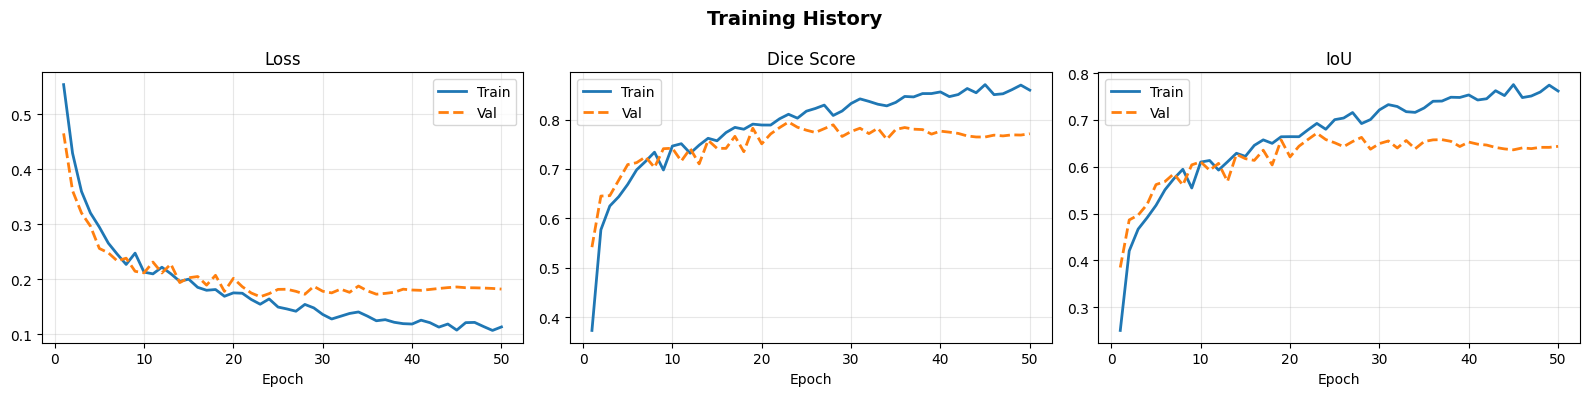

In [11]:
epochs = range(1, CFG.NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training History", fontsize=14, fontweight="bold")

plots = [
    ("Loss",       "train_loss", "val_loss"),
    ("Dice Score", "train_dice", "val_dice"),
    ("IoU",        "train_iou",  "val_iou"),
]

for ax, (title, train_key, val_key) in zip(axes, plots):
    ax.plot(epochs, history[train_key], label="Train", linewidth=2)
    ax.plot(epochs, history[val_key],   label="Val",   linewidth=2, linestyle="--")
    ax.set_title(title);  ax.set_xlabel("Epoch")
    ax.legend();          ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG.SAVE_DIR, "training_curves.png"), dpi=120)
plt.show()

## 11. Visualization — Prediction Overlay

C:\Users\dellg\AppData\Local\Temp\ipykernel_3120\670701265.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio

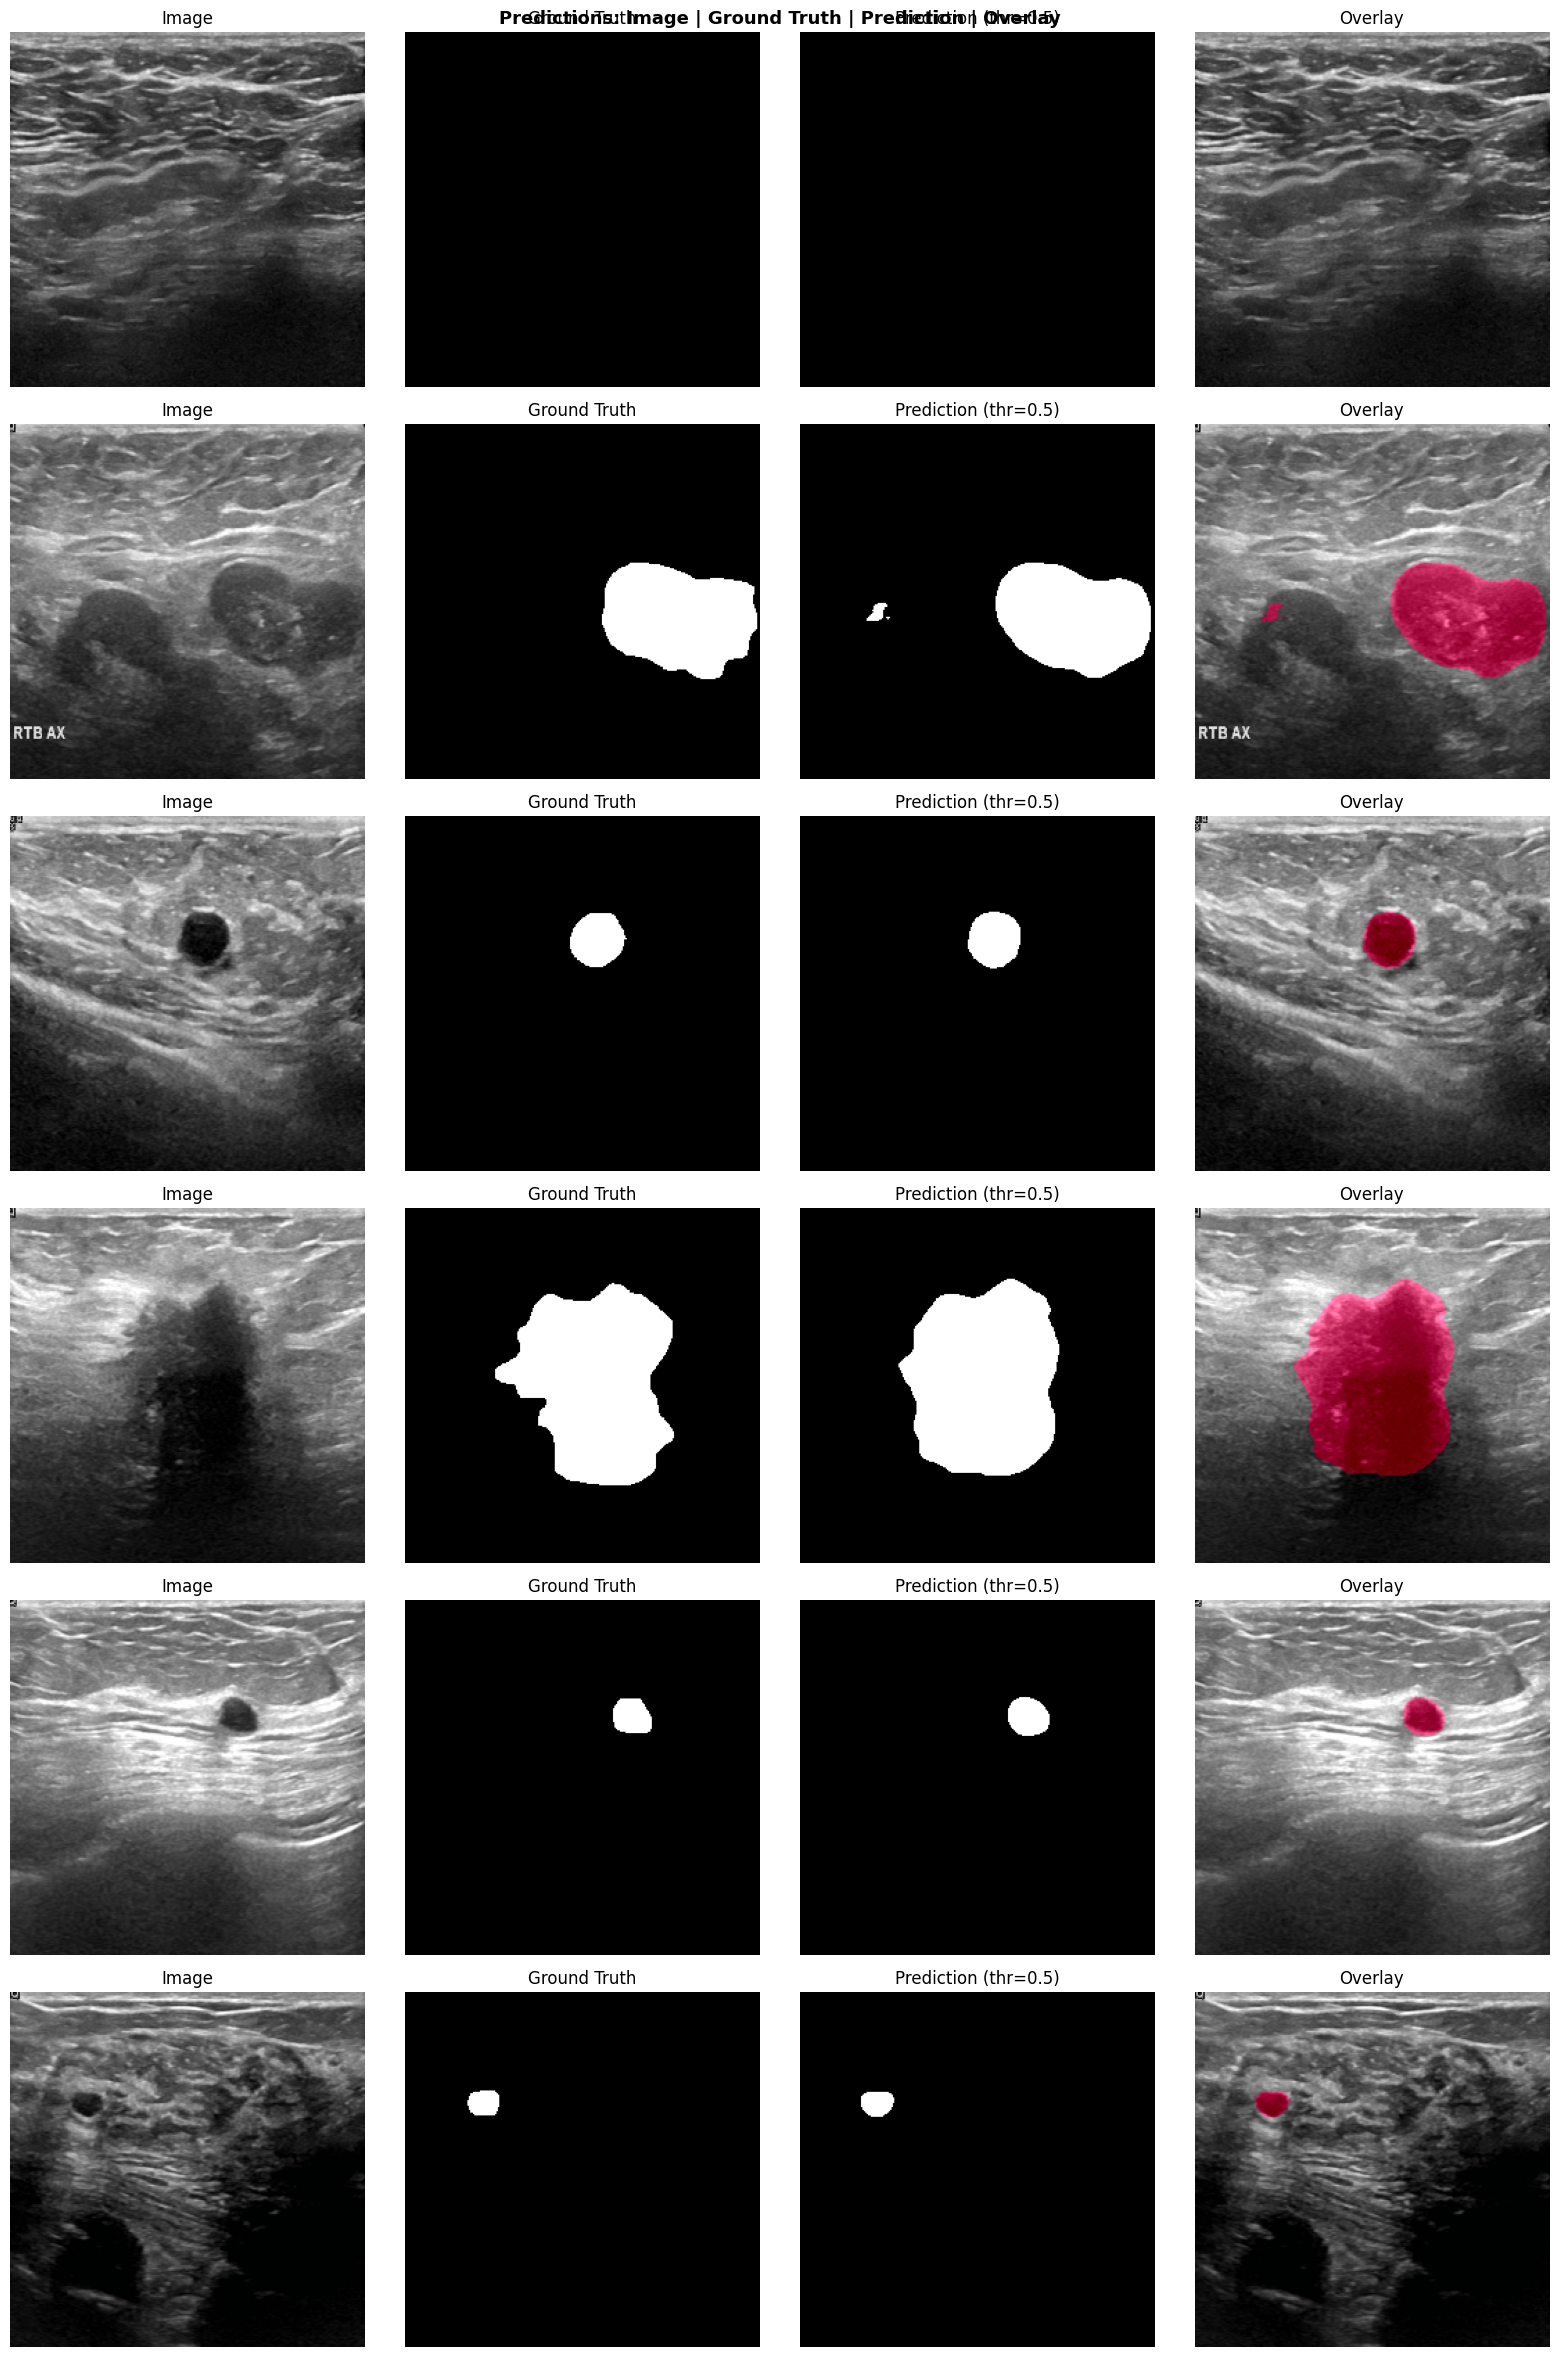

In [12]:
def denormalize(tensor, mean=MEAN, std=STD):
    """Reverse ImageNet normalization for visualization."""
    t = tensor.clone().permute(1, 2, 0).cpu().numpy()  # (H, W, 3)
    t = t * np.array(std) + np.array(mean)
    return np.clip(t, 0, 1)


def visualize_predictions(model, dataset, device, n_samples=6, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
    fig.suptitle("Predictions: Image | Ground Truth | Prediction | Overlay",
                 fontsize=13, fontweight="bold")

    for row_idx, data_idx in enumerate(indices):
        image_tensor, mask_tensor = dataset[data_idx]
        image_tensor = image_tensor.unsqueeze(0).to(device, dtype=torch.float32)

        with torch.no_grad():
            logit = model(image_tensor)                       # (1, 1, H, W)
            prob  = torch.sigmoid(logit).squeeze().cpu().numpy()   # (H, W)
            pred  = (prob > threshold).astype(np.float32)

        img_np  = denormalize(image_tensor.squeeze(0).cpu())  # (H, W, 3)
        gt_np   = mask_tensor.squeeze().cpu().numpy()          # (H, W)

        # Overlay: red channel boosted where prediction is positive
        overlay = img_np.copy()
        overlay[:, :, 0] = np.clip(overlay[:, :, 0] + pred * 0.4, 0, 1)
        overlay[:, :, 1] = np.clip(overlay[:, :, 1] - pred * 0.2, 0, 1)

        ax = axes[row_idx]
        ax[0].imshow(img_np);         ax[0].set_title("Image")
        ax[1].imshow(gt_np, cmap="gray");  ax[1].set_title("Ground Truth")
        ax[2].imshow(pred, cmap="gray");   ax[2].set_title(f"Prediction (thr={threshold})")
        ax[3].imshow(overlay);         ax[3].set_title("Overlay")

        d = dice_score(logit.cpu(), mask_tensor.unsqueeze(0))
        i = iou_score(logit.cpu(),  mask_tensor.unsqueeze(0))
        ax[2].set_xlabel(f"Dice: {d:.3f}  |  IoU: {i:.3f}", fontsize=9)

        for a in ax:
            a.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(CFG.SAVE_DIR, "prediction_samples.png"), dpi=120)
    plt.show()


# Load best model weights before visualizing
model.load_state_dict(torch.load(best_model_path, map_location=CFG.DEVICE))
visualize_predictions(model, val_dataset, CFG.DEVICE, n_samples=6)

## 12. Final Evaluation on Validation Set

In [13]:
@torch.no_grad()
def evaluate_full(model, loader, device, threshold=0.5):
    """Run full evaluation and return per-batch metrics."""
    model.eval()
    all_dice, all_iou = [], []

    for images, masks in loader:
        images = images.to(device, dtype=torch.float32)
        masks  = masks.to(device,  dtype=torch.float32)
        logits = model(images)
        all_dice.append(dice_score(logits, masks, threshold))
        all_iou.append(iou_score(logits,   masks, threshold))

    mean_dice = np.mean(all_dice)
    mean_iou  = np.mean(all_iou)
    return mean_dice, mean_iou


model.load_state_dict(torch.load(best_model_path, map_location=CFG.DEVICE))
final_dice, final_iou = evaluate_full(model, val_loader, CFG.DEVICE)

print("\n" + "=" * 40)
print("  FINAL VALIDATION RESULTS")
print("=" * 40)
print(f"  Dice Score : {final_dice:.4f}")
print(f"  IoU Score  : {final_iou:.4f}")
print("=" * 40)

C:\Users\dellg\AppData\Local\Temp\ipykernel_3120\3589577806.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locati


  FINAL VALIDATION RESULTS
  Dice Score : 0.7949
  IoU Score  : 0.6717


## 13. Save Predicted Masks to Disk
These binary predicted masks will be used later as input features for the classification stage.

In [16]:
@torch.no_grad()
def save_predicted_masks(model, image_paths, mask_dir, device,
                         size=CFG.IMAGE_SIZE, threshold=0.5):
    """
    Run inference on all images and save binary predicted masks as PNG.
    Output filenames mirror input filenames with '_pred_mask' suffix.
    """
    model.eval()

    # Inference transform (no augmentation)
    infer_transform = A.Compose([
        A.Resize(size, size),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

    for img_path in image_paths:
        # Load & preprocess
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        augmented = infer_transform(image=image)
        tensor = augmented["image"].unsqueeze(0).to(device, dtype=torch.float32)

        # Inference
        logit = model(tensor)                              # (1, 1, H, W)
        prob  = torch.sigmoid(logit).squeeze().cpu().numpy()  # (H, W) float
        pred  = (prob > threshold).astype(np.uint8) * 255     # binary 0/255

        # Save
        base      = Path(img_path).stem
        out_fname = base + "_pred_mask.png"
        out_path  = os.path.join(mask_dir, out_fname)
        cv2.imwrite(out_path, pred)

    print(f"\n✅ {len(image_paths)} predicted masks saved to: {mask_dir}")


# Save predictions for ALL images (train + val)
save_predicted_masks(model, all_images, CFG.PRED_DIR, CFG.DEVICE)

# Confirm output
saved = glob(os.path.join(CFG.PRED_DIR, "*.png"))
print(f"Files in predicted_masks/: {len(saved)}")


✅ 780 predicted masks saved to: C:\ornekler\jupyter\deep_learning\breast-cancer\predicted_masks
Files in predicted_masks/: 780
